## 고객 데이터로 어떤 통계적 차이를 발견할 수 있을까?

Mall Customers 데이터셋(200명)으로 성별·연령대·소득·지출 점수 간의 통계적 유의성을 검정했다.

단순 평균 비교에서 벗어나, **그 차이가 우연인지 아닌지**를 통계적으로 확인하는 것이 목표다.

### 분석 진행 내용
- EDA + 이상치 탐지 (IQR 기반)
- 독립표본 t-검정: 성별에 따른 지출 점수 차이 검정
- 일원분산분석(ANOVA): 연령대별 지출 점수 차이 검정
- Tukey HSD 사후 분석: 유의한 연령대 쌍 특정
- 카이제곱 독립성 검정: 성별 × 소득 등급 연관성 검정
- 상관분석: 나이·소득·지출 점수 간 상관관계 확인

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 폰트 설정
import matplotlib.font_manager as fm
# 글꼴 경로 설정
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()
# 폰트 설정
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus']=False

df = pd.read_csv('C:/Users/user/vs_code/data/Mall_Customers.csv', sep =',')

# 가설검정 실습
1. EDA
2. 이상치 탐지
3. 모수적 검정
4. 비모수적 검정 

## 1. EDA

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


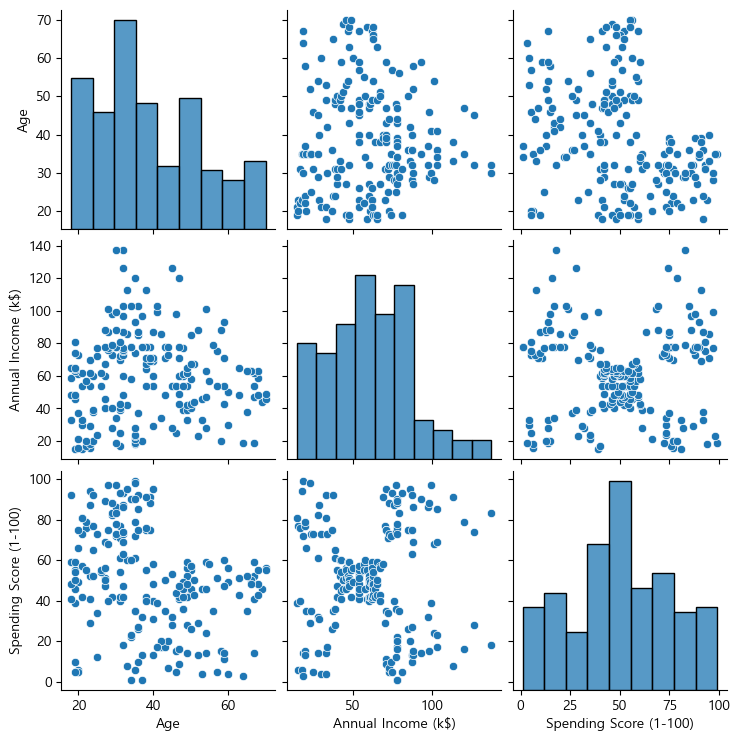

In [ ]:
sns.pairplot(df.iloc[: , 1:])

# 데이터를 살펴봤을 떄 


## 2. 이상치 탐지

In [50]:
# 이상치 확인
q1 = df['Annual Income (k$)'].quantile(0.25)
q3 = df['Annual Income (k$)'].quantile(0.75)
iqr = q3 - q1

maximum = (1.5*iqr) + q3
minimum = q1 - (1.5*iqr)

outliers_cond = (df['Annual Income (k$)'] < minimum) | (df['Annual Income (k$)'] > maximum)

outliers = df[outliers_cond]
outliers


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


In [44]:
# 이상치를 제외한 df


new_df = df[~outliers_cond]
new_df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28


### 박스플롯

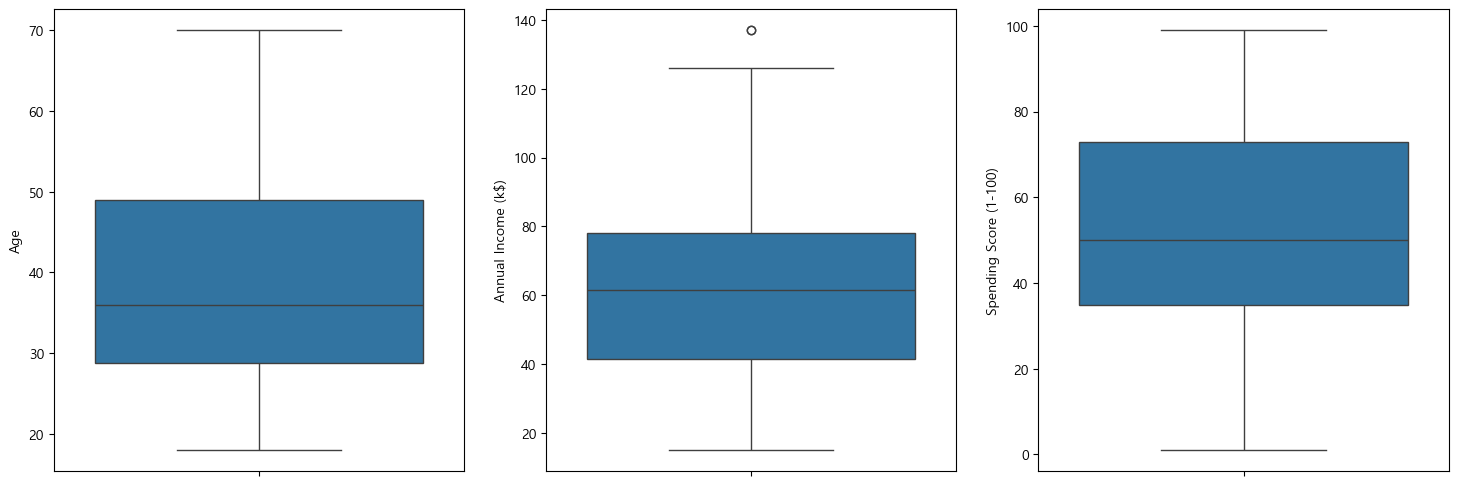

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(y=df['Age'], ax=axes[0])
sns.boxplot(y=df['Annual Income (k$)'], ax=axes[1])
sns.boxplot(y=df['Spending Score (1-100)'], ax=axes[2])

plt.subplots_adjust(wspace=0.2)

plt.show()

# 3. 가설 검정
## 3.1 모수적 검정

### 3.1.1. 독립표본 t-검정
- 성별에 따른 지출 점수 차이(독립표본 t_검정)
- p_val < 0.5  => 대립가설 채택
- 성별에 따른 지출 점수 차이는 존재한다.

In [55]:
# 데이터 슬라이싱
male = df[df["Gender"]=='Male']
female = df[df["Gender"]=='Female']

# spending_score
male_spending_sc = male['Spending Score (1-100)']
female_spending_sc = female['Spending Score (1-100)']

In [66]:
from scipy.stats import ttest_ind

t_stats, p_val = ttest_ind(male_spending_sc, female_spending_sc)
print(f't_stats : {t_stats:.7f}')
print(f'p_val : {p_val:.7f}')

t_stats : -0.8190464
p_val : 0.4137447


### 3.1.2. ANOVA
- 연령대별 지출 점수 차이 (ANOVA)
- 연령대 
- 10대 데이터의 샘플 수가 조금 적음. 비모수적 방법을 고려할 수도 있겠음.

In [88]:
# 연령대 최소 최대 확인
print(df['Age'].min())
print(df['Age'].max())


# 10대
# 20대
# 30대
# 40대
# 50대 이상

teen = df[df["Age"] < 20]['Spending Score (1-100)']
adult = df[(df["Age"] >= 20) & (df["Age"] < 30)]['Spending Score (1-100)']
thirtys = df[(df["Age"] >= 30) & (df["Age"] < 40)]['Spending Score (1-100)']
fortys = df[(df["Age"] >= 40) & (df["Age"] < 50)]['Spending Score (1-100)']
over_fiftys = df[df["Age"] >= 50]['Spending Score (1-100)']

print("-------------------")
print("<데이터 개수>")

print(f'10대 : {len(teen)}')
print(f'20대 : {len(adult)}')
print(f'30대 : {len(thirtys)}')
print(f'40대 : {len(fortys)}')
print(f'50대 이상 : {len(over_fiftys)}')

18
70
-------------------
<데이터 개수>
10대 : 12
20대 : 43
30대 : 61
40대 : 39
50대 이상 : 45


In [90]:
from scipy.stats import f_oneway

# 귀무가설 : 다섯 그룹의 평균간 차이는 없다.
h0 = "다섯 집단의 평균의 차이가 없다."
# 대립가설 : 다섯 그룹간 평균의 차이는 있다.
h1 = "다섯 집단의 평균의 차이가 있다."
f_stat, p_val = stats.f_oneway(teen, adult, thirtys, fortys, over_fiftys)
a = 0.05

if p_val > a:
    print(f"p_val: {p_val} / {h0}")
else:
    print(f"p_val: {p_val} / {h1}")


p_val: 1.072563418958769e-09 / 다섯 집단의 평균의 차이가 있다.


### 3.2.3. 사후 분석(Post Hoc Test)  
- pairwise_tukeyhed 로 사후분석 수행

- 사후 분석 결과 차이가 유의한 그룹
    - 20대 vs 40대
    - 20대 vs 50대
    - 30대 vs 40대
    - 30대 vs 50대 이상

In [92]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [93]:
# 사후 분석을 위한 연령대 컬럼 생성

# 연령대 구분 함수 정의
def age_group(age):
    if age < 20:
        return "10대"
    elif age < 30:
        return "20대"
    elif age < 40:
        return "30대"
    elif age < 50:
        return "40대"
    else:
        return "50대 이상"

# 연령대 컬럼 생성
df['age_group'] = df['Age'].apply(age_group)


In [94]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),age_group
0,1,Male,19,15,39,10대
1,2,Male,21,15,81,20대
2,3,Female,20,16,6,20대
3,4,Female,23,16,77,20대
4,5,Female,31,17,40,30대
...,...,...,...,...,...,...
195,196,Female,35,120,79,30대
196,197,Female,45,126,28,40대
197,198,Male,32,126,74,30대
198,199,Male,32,137,18,30대


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd (endog= df['Spending Score (1-100)'] , groups =df['age_group'], alpha = 0.05 )
print(tukey)

# 유의한 그룹

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
   10대    20대  15.4535 0.2466  -5.3086  36.2156  False
   10대    30대  14.5984 0.2691  -5.4843   34.681  False
   10대    40대 -11.5513  0.554 -32.5444   9.4419  False
   10대 50대 이상     -8.1 0.8169 -28.7612  12.5612  False
   20대    30대  -0.8551 0.9997  -13.518  11.8078  False
   20대    40대 -27.0048    0.0 -41.0671 -12.9425   True
   20대 50대 이상 -23.5535    0.0 -37.1153  -9.9917   True
   30대    40대 -26.1496    0.0 -39.1879 -13.1114   True
   30대 50대 이상 -22.6984    0.0 -35.1951 -10.2016   True
   40대 50대 이상   3.4513 0.9599 -10.4616  17.3641  False
------------------------------------------------------


### 3.2.4. 독립성 검정
성별과 소득 등급 간 독립성 (카이제곱 검정)
- 두 변수가 서로에게 영향을 주는지 검정한다.
- 귀무가설 : 두 변수는 연관이 없다.
- 대립가설 : 두 변수는 연관이 있다. 독립이 아니다.

결론 : 두 변수는 연관이 없다. => 독립이다.

In [98]:
# 독립성 검정을 위해서는 교차표를 생성해야함

# 소득 구간화
df['income_group'] = pd.cut(df['Annual Income (k$)'],
                            bins=[0, 30, 60, 90, 150],
                            labels=['Low', 'Mid', 'High', 'Very High'])

# 교차표
contingency = pd.crosstab(df['Gender'], df['income_group'])

# 카이제곱 검정
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi2: {chi2:.4f}, p-value: {p:.4f}")

Chi2: 2.2586, p-value: 0.5205


In [112]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),age_group,income_group
0,1,Male,19,15,39,10대,Low
1,2,Male,21,15,81,20대,Low
2,3,Female,20,16,6,20대,Low
3,4,Female,23,16,77,20대,Low
4,5,Female,31,17,40,30대,Low
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,30대,Very High
196,197,Female,45,126,28,40대,Very High
197,198,Male,32,126,74,30대,Very High
198,199,Male,32,137,18,30대,Very High


# 상관분석
- 고객의 나이, 연간소득, 지출 점수 사이의 상관관계
- 연속형 변수 간 상관분석
- 상관관계가 있다고 볼만한 데이터가 없음

Text(0.5, 1.0, '연속형 변수 간 상관분석')

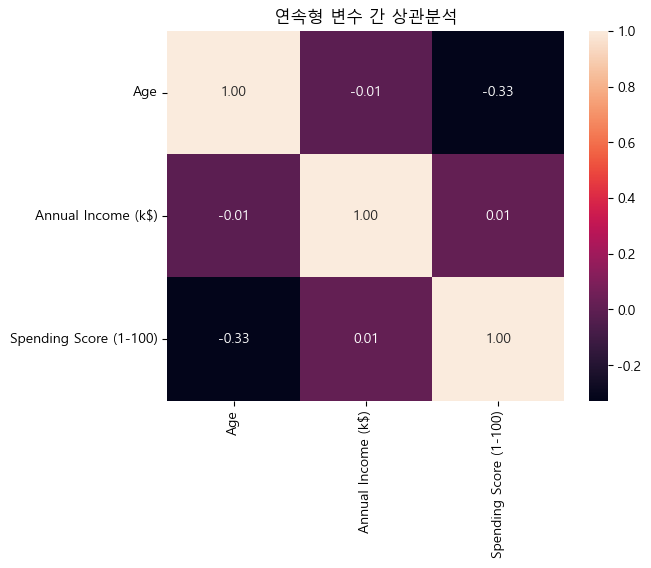

In [ ]:
# 연속형 변수 추출

numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols[1:]

# 상관 계수
# 피어슨 상관계수 
corr_matrix = df[numeric_cols].corr()

# 시각화
sns.heatmap(corr_matrix, annot = True, fmt=".2f")
plt.title("연속형 변수 간 상관분석")

# 분석 요약

- 남, 여 성별에 따른 지출 점수 차이는 존재한다.
- 연령대 별 지출 점수 차이는 존재한다.
- 사후분석 결과 연령대 별 지출 점수 차이가 유의한 그룹은 다음과 같다.
    - 20대 vs 40대
    - 20대 vs 50대
    - 30대 vs 40대
    - 30대 vs 50대 이상

- 데이터 개수는 다음과 같다
   - 10대 : 12
   - 20대 : 43
   - 30대 : 61
   - 40대 : 39
   - 50대 이상 : 45

- 나이와 구매 지출 점수는 약한 음의 상관관계가 있다.
- 성별과 소득 등급은 연관이 없다. (독립이다.)


## 결론
- 분석 결과 연령별, 성별로 구매 지출 점수 차이가 존재하기에 이에 맞는 세그먼트를 만들고 마케팅을 진행할 수 있다.
- 20대/30대 vs 40대/50대의 차이가 가장 유의하다 할 수 있다. 이에 맞는 제품군을 추천할 수 있다.
- 10대 데이터 샘플 수가 적다. 비모수적 방식으로 검정하거나 추가적으로 데이터를 모집한 후 검정하는 것을 추천한다.
- 나이가 많을 수록 소비력이 조금 떨어진다. 구매 유도를 위해 쿠폰 등을 뿌리면 구매력이 올라갈 수도 있다.